<a href="https://colab.research.google.com/github/grasht/projects_ML_HW_6/blob/main/HW6_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1 Reinforcement Learning

**Enviornment**: Grid World.

**Iteration Type**: Value. The Bellman Equation guarantees that repeatedly updating the values for the next state given the current state and an action will eventually converge (delta < threshold) and result in an optimal policy.

**Why this set up is an MDP:** This is an MDP (Markov Decision Process) because the future depends only on the present state and action, not the full history. In other words it follows the Markov Property. Further, you can define this set up using the (S,A,P,R,gamma) structure of an MDP.

**S**: The squares in the grid.

**A**: Actions available (up, down, left, right).

**P**: Transition model is 100% for each direction.

**R**: Feedback is immediate (G = +1, _ = -1, else = +0).

**gamma**: a parameter.

For the grid visual - --> blank space, _ --> obstacle ("pit"), G --> Reward ("goal").

In [ ]:
import numpy as np

Problem Example

In [ ]:
grid_size = 5

#up, down, left, right respectively
actions = [(-1,0), (1, 0), (0, -1), (0, 1)]

gamma = 0.8 #discount
theta = 1e-4 #threshold

#Rewards
rewards = np.zeros((grid_size, grid_size))
terminal_states = [(0,3), (3, 3), (3,4)]
for idx, (row, col) in enumerate(terminal_states):
  if idx == len(terminal_states)-1:
    rewards[row, col] = 1 #Goal
  else:
    rewards[row, col] = -1 #Obstacle



val_func = np.zeros((grid_size, grid_size))

In [ ]:
def get_next_state(state, action):
    next_state = (state[0] + action[0], state[1] + action[1])

    #Enforce Bounds
    if next_state[0] < 0 or next_state[0] >= grid_size or next_state[1] < 0 or next_state[1] >= grid_size:
        next_state = state

    return next_state

def value_iteration():
  global val_func
  while True:
    delta = 0
    new_V = np.copy(val_func)

    for i in range(grid_size):
      for j in range(grid_size):
        if((i, j) in terminal_states):
          new_V[i, j] = rewards[i, j]
          continue

        state_values = []
        for action in actions:
          next_state = get_next_state((i, j), action)
          reward = rewards[next_state[0], next_state[1]]
          state_values.append(reward + gamma * val_func[next_state[0], next_state[1]])

        best_value = max(state_values)
        new_V[i, j] = best_value
        delta = max(delta, np.abs(new_V[i, j] - val_func[i, j]))

    val_func = new_V

    if delta < theta:
      break

def extract_policy():
  policy = np.empty((grid_size, grid_size), dtype=object)

  for i in range(grid_size):
    for j in range(grid_size):
      if (i,j) in terminal_states:
        if rewards[(i, j)] == 1:
          policy[i, j] = 'G'
        else:
          policy[i, j] = '_'
        continue

      action_values = []
      for action in actions:
        next_state = get_next_state((i, j), action)
        reward = rewards[next_state[0], next_state[1]]
        action_values.append(reward + gamma * val_func[next_state[0], next_state[1]])

      best_action = np.argmax(action_values)
      policy[i, j] = actions[best_action]

  return policy

In [ ]:
action_symbols = {
    (-1, 0): '↑',
    (1, 0): '↓',
    (0, -1): '←',
    (0, 1): '→'
}

def readable_policy(policy):
  r = ''
  for p in policy:
    r+='\n'
    for a in p:
      if a in action_symbols:
        r += action_symbols[a]
      else:
        r += a

  return r

def print_grid(goals, obstacles):
    for i in range(grid_size):
        row = ""
        for j in range(grid_size):

            if (i, j) in goals:
                row += " G "
            elif (i, j) in obstacles:
                row += " _ "
            else:
                row += " - "

        print(row)


# Run Value Iteration

In [ ]:
value_iteration()
policy = extract_policy()

print(f"Value Function: {np.round(val_func, 2)}.")
print(f"\nPolicy:{policy}.")
print(f"\nPolicy:{readable_policy(policy)}.")

**Output**:

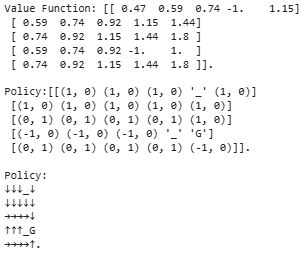

# Example - Vary the reward design.

Optional Reward with balanced gamma

In [ ]:
grid_size = 5

#up, down, left, right respectively
actions = [(-1,0), (1, 0), (0, -1), (0, 1)]

gamma = 0.5 #discount
theta = 1e-4 #threshold

#Rewards
rewards = np.zeros((grid_size, grid_size))
terminal_states = [(0,3), (3, 3), (4,4)]
optional_rewards = []
for idx, (row, col) in enumerate(terminal_states):
  if idx == len(terminal_states)-1:
    rewards[row, col] = 1 #Goal
  else:
    rewards[row, col] = -1 #Obstacle

for idx, (row, col) in enumerate(optional_rewards):
  rewards[row, col] = 0.1

val_func = np.zeros((grid_size, grid_size))

value_iteration()
policy = extract_policy()
non_terminal_obs = optional_rewards

print_grid([(4,4)],[(0,3), (3, 3)])
print(f"Value Function: {np.round(val_func, 2)}.")
print(f"\nPolicy:{policy}.")
print(f"\nPolicy:{readable_policy(policy)}.")

In [ ]:
grid_size = 5

#up, down, left, right respectively
actions = [(-1,0), (1, 0), (0, -1), (0, 1)]

gamma = 0.5 #discount
theta = 1e-4 #threshold

#Rewards
rewards = np.zeros((grid_size, grid_size))
terminal_states = [(0,3), (3, 3), (4,4)]
optional_rewards = [(3,4)]
for idx, (row, col) in enumerate(terminal_states):
  if idx == len(terminal_states)-1:
    rewards[row, col] = 1 #Goal
  else:
    rewards[row, col] = -1 #Obstacle

for idx, (row, col) in enumerate(optional_rewards):
  rewards[row, col] = 0.5

val_func = np.zeros((grid_size, grid_size))

value_iteration()
policy = extract_policy()
non_terminal_obs = optional_rewards

print_grid([(4,4), (3,4)],[(0,3), (3, 3)])
print(f"Value Function: {np.round(val_func, 2)}.")
print(f"\nPolicy:{policy}.")
print(f"\nPolicy:{readable_policy(policy)}.")

**Results**: Adding an optional (non-terminal) goal will actually change the policy and can, like with this case, change the resutling path (assuming you start from the top left). Instead of going straight down and then right, the policy favors going right to get the optinal reward. (All rewards are pictured as G's, but only the bottom right is terminal). (_ is obtacles i.e. "pits" and - are blank spaces.)

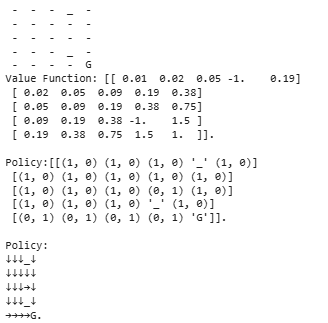
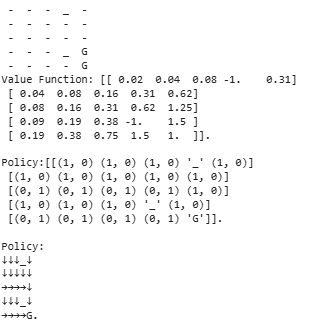

# Non Terminal Obstacles With Optional Reward

Rewards outweigh obstacles. Vary Gamma.

In [ ]:
grid_size = 5

#up, down, left, right respectively
actions = [(-1,0), (1, 0), (0, -1), (0, 1)]

gamma = 0.8 #discount
theta = 1e-4 #threshold

#Rewards
rewards = np.zeros((grid_size, grid_size))
terminal_states = [(4,4)]
optional_rewards = [(3,4)]
non_terminal_obs = [(0,3), (3, 3), (2,4)]
for row, col in terminal_states:
    rewards[row, col] = 1 #Goal

for row, col in optional_rewards:
  rewards[row, col] = .3

for row, col in non_terminal_obs:
  rewards[row, col] = -.2

val_func = np.zeros((grid_size, grid_size))

value_iteration()
policy = extract_policy()

print_grid(terminal_states + optional_rewards, non_terminal_obs)
print(f"Value Function: {np.round(val_func, 2)}.")
print(f"\nPolicy:{policy}.")
print(f"\nPolicy:{readable_policy(policy)}.")

In [ ]:
grid_size = 5

#up, down, left, right respectively
actions = [(-1,0), (1, 0), (0, -1), (0, 1)]

gamma = 0.2 #discount
theta = 1e-4 #threshold

#Rewards
rewards = np.zeros((grid_size, grid_size))
terminal_states = [(4,4)]
optional_rewards = [(3,4)]
non_terminal_obs = [(0,3), (3, 3), (2,4)]
for row, col in terminal_states:
    rewards[row, col] = 1 #Goal

for row, col in optional_rewards:
  rewards[row, col] = .3

for row, col in non_terminal_obs:
  rewards[row, col] = -.2

val_func = np.zeros((grid_size, grid_size))

value_iteration()
policy = extract_policy()

print_grid(terminal_states + optional_rewards, non_terminal_obs)
print(f"Value Function: {np.round(val_func, 2)}.")
print(f"\nPolicy:{policy}.")
print(f"\nPolicy:{readable_policy(policy)}.")

**Results**: Here we cana see that the larger gamma is able to see that the immediate penalty of a non terminal obstacle is worth getting the optinal objective.

Left: Gamma = 0.8. Right: Gamma = 0.2.

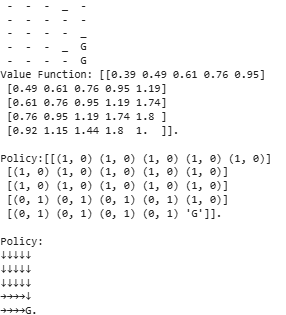
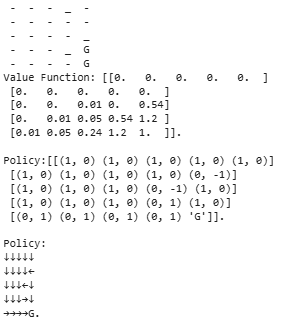

# Informative Bug

Punishing obstacles (-1) and modest rewards (.5). One with Gamma 0.8 and the other 0.2.

In [ ]:
grid_size = 5

#up, down, left, right respectively
actions = [(-1,0), (1, 0), (0, -1), (0, 1)]

gamma = 0.8 #discount
theta = 1e-4 #threshold

#Rewards
rewards = np.zeros((grid_size, grid_size))
terminal_states = [(4,4)]
optional_rewards = [(3,4)]
non_terminal_obs = [(0,3), (3, 3), (2,4)]
for row, col in terminal_states:
    rewards[row, col] = 1 #Goal

for row, col in optional_rewards:
  rewards[row, col] = .5

for row, col in non_terminal_obs:
  rewards[row, col] = -1

val_func = np.zeros((grid_size, grid_size))

value_iteration()
policy = extract_policy()

print_grid(terminal_states + optional_rewards, non_terminal_obs)
print(f"Value Function: {np.round(val_func, 2)}.")
print(f"\nPolicy:{policy}.")
print(f"\nPolicy:{readable_policy(policy)}.")

In [ ]:
grid_size = 5

#up, down, left, right respectively
actions = [(-1,0), (1, 0), (0, -1), (0, 1)]

gamma = 0.2 #discount
theta = 1e-4 #threshold

#Rewards
rewards = np.zeros((grid_size, grid_size))
terminal_states = [(4,4)]
optional_rewards = [(3,4)]
non_terminal_obs = [(0,3), (3, 3), (2,4)]
for row, col in terminal_states:
    rewards[row, col] = 1 #Goal

for row, col in optional_rewards:
  rewards[row, col] = .5

for row, col in non_terminal_obs:
  rewards[row, col] = -1

val_func = np.zeros((grid_size, grid_size))

value_iteration()
policy = extract_policy()

print_grid(terminal_states + optional_rewards, non_terminal_obs)
print(f"Value Function: {np.round(val_func, 2)}.")
print(f"\nPolicy:{policy}.")
print(f"\nPolicy:{readable_policy(policy)}.")

**Results**: Here we see an interesting result that indicates an issue with our experimental design, but highlights an important difference when varying gamma. The arrow pointing out of bounds creates an infinite loop where the policy is attempting to return to the same spot by bumping into the boundry. The high forethought from higher gamma allowed it to identify a way to infinitely farm the optional reward rather than taking the immediate larger reward of going to the goal. Ideally we should have assigned a penalty to the boundary or handled out of bounds some other way, but this is still an interesting result.

Left: Gamma = 0.8. Right: Gamma = 0.2.

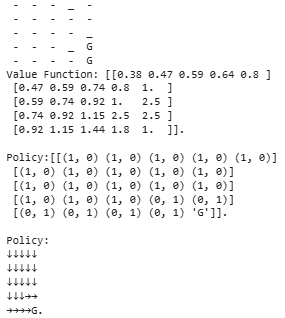
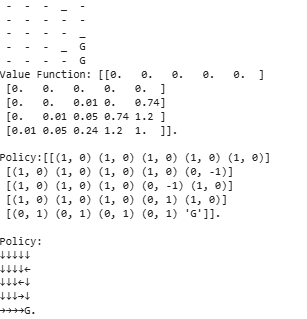